# **🚧 Automated Road Damage Classification**
## ╰┈➤ Project: Pothole, Crack, and Manhole Detection

**Dataset**
- **Class 0:** Pothole
- **Class 1:** Crack
- **Class 2:** Manhole

In [1]:
# Data processing
import pandas as pd
import numpy as np

# File handling
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models # model architecture
from tensorflow.keras.applications import ResNet50 # transfer learning model
from tensorflow.keras.preprocessing.image import ImageDataGenerator # data augmentation

# Model evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Hide warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:

print("TF version:", tf.__version__)

TF version: 2.20.0


#  **Data Load**

In [3]:
TRAIN_DIR = "D:\\Intern Project\\Final Project\\data\\train"
TEST_DIR  = "D:\\Intern Project\\Final Project\\data\\test"

In [4]:
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Test exists: True


# **Data Preprocessed steps :**

### **1. Resize images to a fixed input size (224×224)**

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,  
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True)


Found 1607 files belonging to 3 classes.
Using 1286 files for training.


In [7]:
len(train_ds)

41

In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,   
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True)

Found 1607 files belonging to 3 classes.
Using 321 files for validation.


In [9]:
len(val_ds)

11

In [10]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False)

Found 402 files belonging to 3 classes.


In [11]:
len(test_ds)

13

In [12]:
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

Classes: ['0_Pothole', '1_Crack', '2_Manhole']
Number of classes: 3


In [13]:
CLASSES   = ['0_Pothole', '1_Crack', '2_Manhole']
NUM_CLASSES = 3

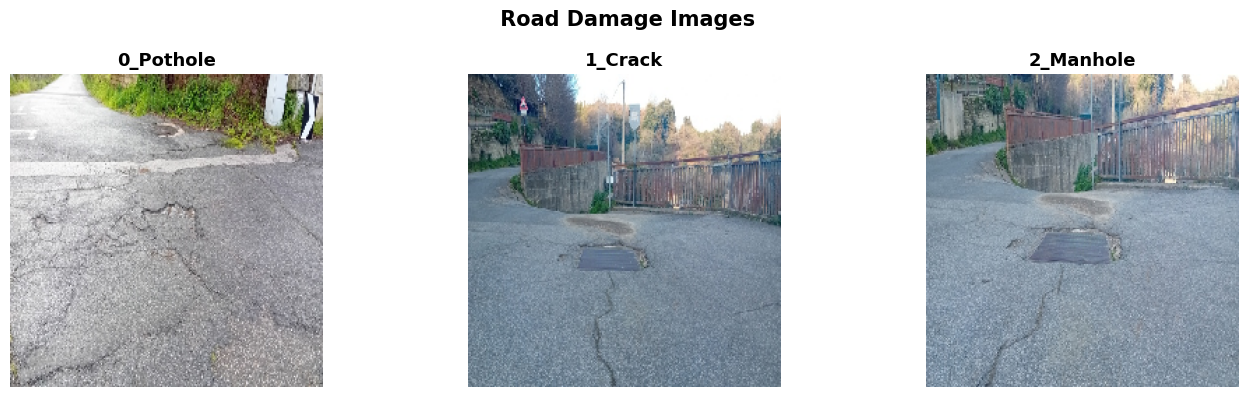

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, cls in enumerate(CLASSES):
    img_path = os.path.join(TRAIN_DIR, cls, os.listdir(os.path.join(TRAIN_DIR, cls))[0])
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=13, fontweight='bold')
    axes[i].axis('off')
plt.suptitle(' Road Damage Images', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### **Data Pipeline Optimization (Cache/Prefetch)**

In [15]:
AUTOTUNE = tf.data.AUTOTUNE # Faster data loading and then  Automatic tuning

In [16]:
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# **2 . Data Augmentation and Normalize (0–1)**

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_aug")

normalizer = layers.Rescaling(1./255, name="rescale_0_1") # Apply Normalize pixel values to [0, 1]

In [18]:
for images, labels in train_ds.take(1):
    
    print("Before Normalization")
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())
    
    # Apply normalization
    norm_images = normalizer(images)
    
    print("\nAfter Normalization")
    print("Min pixel value:", tf.reduce_min(norm_images).numpy())
    print("Max pixel value:", tf.reduce_max(norm_images).numpy())
    
    break

Before Normalization
Min pixel value: 0.0
Max pixel value: 255.0

After Normalization
Min pixel value: 0.0
Max pixel value: 1.0


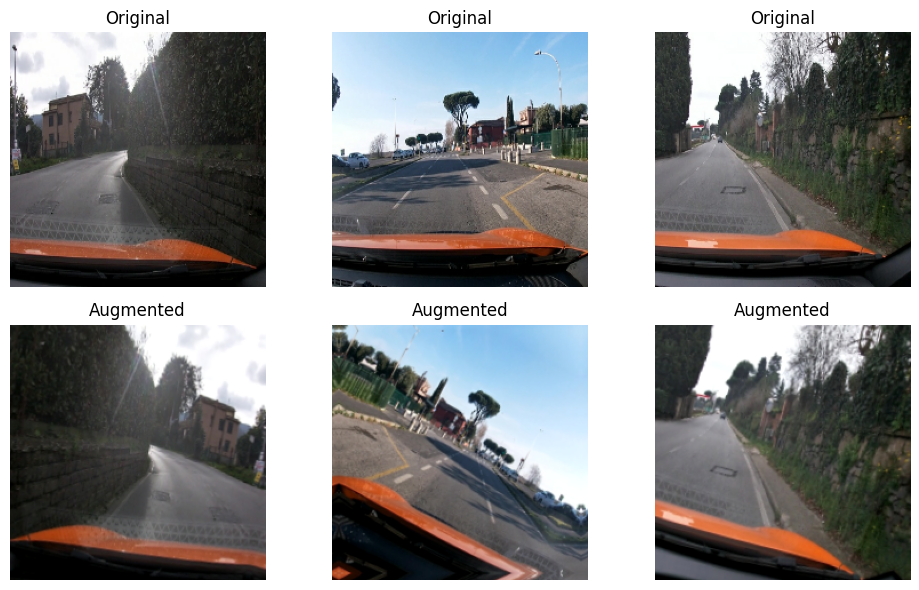

In [19]:
plt.figure(figsize=(10,6))

for images, labels in train_ds.take(1):
    
    # Show original
    for i in range(3):
        ax = plt.subplot(2, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Original")
        plt.axis("off")
    
    # Show augmented
    aug_images = data_augmentation(images)
    
    for i in range(3):
        ax = plt.subplot(2, 3, i+4)
        plt.imshow(aug_images[i].numpy().astype("uint8"))
        plt.title("Augmented")
        plt.axis("off")
        
    break

plt.tight_layout()
plt.show()

# **4 . Handle the class Balanced (or) Imbalanced**

In [20]:
counts = np.zeros(NUM_CLASSES, dtype=int)

for _, label in train_ds.unbatch():
    counts[int(label.numpy())] += 1

total = counts.sum()

class_weight = {}

for i in range(NUM_CLASSES):
    if counts[i] == 0:
        class_weight[i] = 1.0  # avoid division error
    else:
        class_weight[i] = total / (NUM_CLASSES * counts[i])

print("Counts:", dict(zip(class_names, counts)))
print("Class weight:", class_weight)

Counts: {'0_Pothole': np.int64(305), '1_Crack': np.int64(627), '2_Manhole': np.int64(354)}
Class weight: {0: np.float64(1.4054644808743169), 1: np.float64(0.68367889420521), 2: np.float64(1.2109227871939736)}


In [21]:
max_count = counts.max()
min_count = counts.min()

print("Max Count:", max_count)
print("Min Count:", min_count)

Max Count: 627
Min Count: 305


In [22]:
ratio = max_count / min_count
print("Ratio:", ratio)

if ratio > 2:
    print("⚠️ Imbalance detected ")
else:
    print("✔️ Classes are balanced ")

Ratio: 2.055737704918033
⚠️ Imbalance detected 


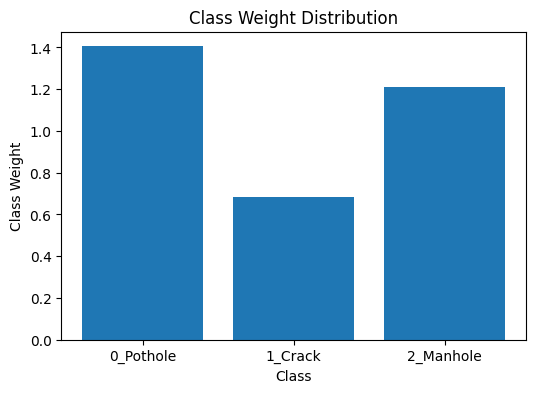

In [23]:
# Plot Bar Chart
plt.figure(figsize=(6,4))

# Convert dictionary values to list
weights = list(class_weight.values())

plt.bar(range(NUM_CLASSES), weights)

plt.xlabel("Class")
plt.ylabel("Class Weight")
plt.title("Class Weight Distribution")

plt.xticks(range(NUM_CLASSES), class_names)

plt.show()

## **1) . CNN Model**

In [24]:
# 1 . input_layer
baseline_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    normalizer,
    data_augmentation,

    # CNN layer 1
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # CNN layer 2
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # CNN layer 3
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),


                         # features extracted by CNN layers



    #fully connected layers
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"), # hidden layer
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")], name="Baseline_CNN")   # Output layer for 3 classes

In [25]:
# 2. Compile the Model

baseline_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [26]:
# 3. Model Summary
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescale_0_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_aug (Sequential)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# 4. Train the Model (Uses the weights you calculated earlier)
history_baseline = baseline_model.fit( train_ds, validation_data=val_ds, epochs=10, class_weight=class_weight )

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.4199 - loss: 1.1556 - val_accuracy: 0.5171 - val_loss: 1.0300
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.4145 - loss: 1.0815 - val_accuracy: 0.4268 - val_loss: 1.0443
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.4012 - loss: 1.0752 - val_accuracy: 0.4798 - val_loss: 1.0296
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.4456 - loss: 1.0495 - val_accuracy: 0.4798 - val_loss: 1.0188
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.4712 - loss: 1.0434 - val_accuracy: 0.4268 - val_loss: 1.0449
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.4261 - loss: 1.0483 - val_accuracy: 0.5171 - val_loss: 0.9899
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 146s 4s/step - accuracy: 0.4393 - loss: 1.0361 - val_accuracy: 0.4019 - val_loss: 1.1057
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.4549 - loss: 1.0311 - val_accuracy: 0.5421 - val

## **Model Evaluation (Accuracy/Precision/Recall/F1)**

In [29]:
test_loss, test_accuracy =baseline_model.evaluate(test_ds)
print(" Baseline Model Evaluation Results")
print("-" * 30 )
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 902ms/step - accuracy: 0.5075 - loss: 1.0387
 Baseline Model Evaluation Results
------------------------------
Test Loss    : 1.0387
Test Accuracy: 0.5075


In [30]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)


y_pred = np.argmax(baseline_model.predict(test_ds, verbose=0), axis=1)

print(f" Accuracy : {np.mean(y_true == y_pred):.4f}")
print(f" Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" F1-score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

 Accuracy : 0.5075
 Precision: 0.4773
 Recall   : 0.4909
 F1-score : 0.4765


## **Classification Report**

In [31]:
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(
    y_true, 
    y_pred, 
    target_names=['0_Pothole', '1_Crack', '2_Manhole'], 
    output_dict=True)

df = pd.DataFrame(report_dict).T

# 2. Explanation for Color Interpretation
print(" Classification Table View:")
print("-" * 30)
print("🟦 DARK BLUE  : High Value (Model performs well for this class)")
print("⬜ LIGHT BLUE : Low Value  (Model performance needs improvement)")
print("-" * 30)

# 3. Styled Table Display
styled_table = df.style.background_gradient(cmap='Blues').format(precision=2)

display(styled_table)

 Classification Table View:
------------------------------
🟦 DARK BLUE  : High Value (Model performs well for this class)
⬜ LIGHT BLUE : Low Value  (Model performance needs improvement)
------------------------------


,precision,recall,f1-score,support
0_Pothole,0.41,0.59,0.48,94.00
1_Crack,0.69,0.56,0.62,208.00
2_Manhole,0.33,0.33,0.33,100.00
accuracy,0.51,0.51,0.51,0.51
macro avg,0.48,0.49,0.48,402.00
weighted avg,0.54,0.51,0.51,402.00


# **Justification**

In [34]:
print("\nModel Justification:")
print("-" * 30)
print("Baseline CNN Accuracy: 0.51 (moderate performance)")
print("Crack class detected best (Precision: 0.69)")
print("Pothole and Manhole confusion due to similar patterns")
print("Transfer learning models can improve performance\n")


Model Justification:
------------------------------
Baseline CNN Accuracy: 0.51 (moderate performance)
Crack class detected best (Precision: 0.69)
Pothole and Manhole confusion due to similar patterns
Transfer learning models can improve performance



## **Confusion Matrix Heatmap**


--- Confusion Matrix ---
1. 55 → Correct Pothole detections → misclassified as Crack (21) and Manhole (18).
2. 116 → Correct Crack detections → misclassified as Pothole (42) and Manhole (50).
3. 33 → Correct Manhole detections → misclassified as Pothole (37) and Crack (30).
4. Conclusion: Model shows confusion between pothole and manhole classes.



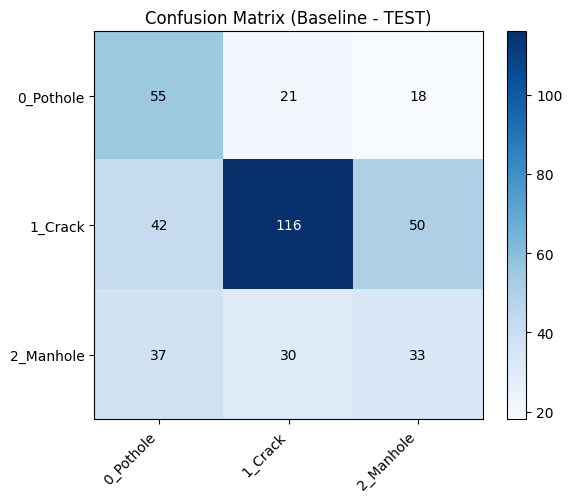

In [41]:
cm = confusion_matrix(y_true, y_pred)

print("\n--- Confusion Matrix ---")

print("1. 55 → Correct Pothole detections → misclassified as Crack (21) and Manhole (18).")

print("2. 116 → Correct Crack detections → misclassified as Pothole (42) and Manhole (50).")

print("3. 33 → Correct Manhole detections → misclassified as Pothole (37) and Crack (30).")

print("4. Conclusion: Model shows confusion between pothole and manhole classes.\n")
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Baseline - TEST)")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.colorbar()
plt.tight_layout()
plt.show()

## **Save Mode**

In [42]:
baseline_model.save("baseline_cnn.h5")
print(" baseline_cnn.h5 saved")

 baseline_cnn.h5 saved


## **2) . Transfer learning using pre-trained models**

## **i ) . MobileNetV2**

###  **Load Pre-trained  (MobileNetV2)**

In [43]:
base_mobilenet = tf.keras.applications.MobileNetV2( input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), include_top=False, weights="imagenet" )
base_mobilenet.trainable = False  

## **Input layers**

In [44]:
mobilenet_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input, name="mobilenet_preprocess"),  # ✅ FIX
    base_mobilenet,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation="softmax")
], name="MobileNetV2_TL")

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_aug (Sequential)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## **Train**

In [45]:
history_mobilenet = mobilenet_model.fit( train_ds,validation_data=val_ds, epochs=8,class_weight=class_weight)

Epoch 1/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.3834 - loss: 1.3188 - val_accuracy: 0.3022 - val_loss: 1.2913
Epoch 2/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.4370 - loss: 1.1626 - val_accuracy: 0.3894 - val_loss: 1.1545
Epoch 3/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.4549 - loss: 1.1153 - val_accuracy: 0.3614 - val_loss: 1.1684
Epoch 4/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.4759 - loss: 1.1014 - val_accuracy: 0.3583 - val_loss: 1.2701
Epoch 5/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5023 - loss: 1.0627 - val_accuracy: 0.3396 - val_loss: 1.3315
Epoch 6/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.5202 - loss: 1.0217 - val_accuracy: 0.4299 - val_loss: 1.0586
Epoch 7/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.5334 - loss: 0.9722 - val_accuracy: 0.4237 - val_loss: 1.1707
Epoch 8/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5334 - loss: 0.9736 - val_accuracy: 0.4735 - val_loss: 1.0603


In [46]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)
print("MobileNetV2 Evaluation Results")
print("-" * 30)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5199 - loss: 0.9708
MobileNetV2 Evaluation Results
------------------------------
Test Loss    : 0.9708
Test Accuracy: 0.5199


## **Fine-Tune Setup**

In [47]:
#  Fine-tune enable
base_mobilenet.trainable = True

#   Unfreeze last 50 layers (30 → 50)
for layer in base_mobilenet.layers[:-50]:
    layer.trainable = False

#  Freeze BatchNormalization layers (stable training)
for layer in base_mobilenet.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print(" Base trainable layers:", sum(l.trainable for l in base_mobilenet.layers))

 Base trainable layers: 33


In [48]:
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy",metrics=["accuracy"])
print(" Fine-tune compile done")

 Fine-tune compile done


## **Fine-Tune Train**

In [49]:
history_mobilenet_ft = mobilenet_model.fit(train_ds, validation_data=val_ds,epochs=10,class_weight=class_weight)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.5544 - loss: 0.9504 - val_accuracy: 0.4548 - val_loss: 1.0383
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.5451 - loss: 0.9388 - val_accuracy: 0.4143 - val_loss: 1.0955
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.5918 - loss: 0.8904 - val_accuracy: 0.4579 - val_loss: 1.0390
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.5537 - loss: 0.9032 - val_accuracy: 0.4455 - val_loss: 1.0606
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.5816 - loss: 0.8566 - val_accuracy: 0.4642 - val_loss: 1.0597
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6050 - loss: 0.8625 - val_accuracy: 0.4579 - val_loss: 1.0394
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.6221 - loss: 0.8499 - val_accuracy: 0.4611 - val_loss: 1.0532
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.6369 - loss: 0.8096 - val_accuracy: 0.5078 - val_loss:

## **Model Evaluation (Accuracy/Precision/Recall/F1)**

In [50]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)

print("\n--- MobileNetV2 Fine-Tuned Results ---")
print("-" * 40 + "\n")
print(f"Test Loss        : {test_loss:.4f}\n")
print(f"Test Accuracy    : {test_accuracy:.4f}\n")

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5373 - loss: 0.9358

--- MobileNetV2 Fine-Tuned Results ---
----------------------------------------

Test Loss        : 0.9358

Test Accuracy    : 0.5373



In [51]:
#  y_true safe
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

#  predictions
y_pred = np.argmax(mobilenet_model.predict(test_ds, verbose=0), axis=1)

print(f" Accuracy : {np.mean(y_true == y_pred):.4f}")
print(f" Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" F1-score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

 Accuracy : 0.5373
 Precision: 0.5581
 Recall   : 0.5740
 F1-score : 0.5368


## **Classification Report**

In [ ]:
print("🟦 DARK BLUE  : High Value (Model performs well in this class)")
print("⬜ LIGHT BLUE : Low Value  (Model performance is weak in this class)")
print("-" * 55)

# Styled Table
styled_table = df.style.background_gradient(cmap='Blues').format(precision=2)
display(styled_table)

🟦 DARK BLUE  : High Value (Model performs well in this class)
⬜ LIGHT BLUE : Low Value  (Model performance is weak in this class)
-------------------------------------------------------


,precision,recall,f1-score,support
0_Pothole,0.41,0.59,0.48,94.00
1_Crack,0.69,0.56,0.62,208.00
2_Manhole,0.33,0.33,0.33,100.00
accuracy,0.51,0.51,0.51,0.51
macro avg,0.48,0.49,0.48,402.00
weighted avg,0.54,0.51,0.51,402.00


## **Confusion Matrix Heatmap**


--- MobileNetV2 Heatmap Justification ---

--- MobileNetV2 Confusion Matrix Explanation ---
62 → Correct pothole detections → some misclassified as crack (13) and manhole (19).
92 → Correct crack detections → some misclassified as pothole (79) and manhole (37).
62 → Correct manhole detections → some misclassified as pothole (24) and crack (14).
Conclusion: Fine-tuning successful → model performs better than the baseline.


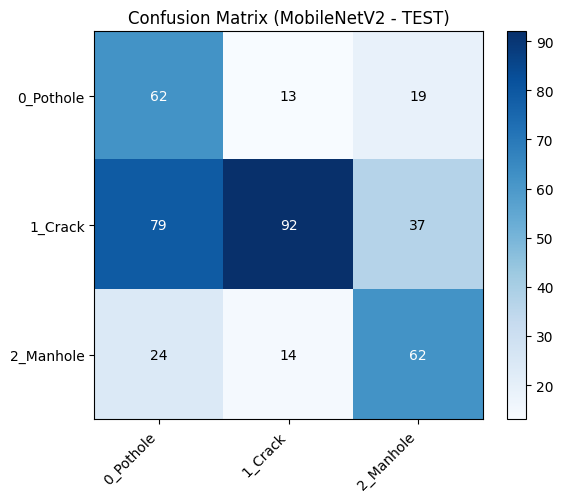

In [56]:
cm = confusion_matrix(y_true, y_pred)
print("\n--- MobileNetV2 Heatmap Justification ---")
print("\n--- MobileNetV2 Confusion Matrix Explanation ---")

print("62 → Correct pothole detections → some misclassified as crack (13) and manhole (19).")

print("92 → Correct crack detections → some misclassified as pothole (79) and manhole (37).")

print("62 → Correct manhole detections → some misclassified as pothole (24) and crack (14).")

print("Conclusion: Fine-tuning successful → model performs better than the baseline.")

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (MobileNetV2 - TEST)")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)

thr = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > thr else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.colorbar()
plt.tight_layout()
plt.show()

## **Save Mode**

In [57]:
mobilenet_model.save("mobilenetv2_road_damage.h5")
print("✅ Saved: mobilenetv2_road_damage.h5")

✅ Saved: mobilenetv2_road_damage.h5


## **ii ) . ResNet50 Model**

###   **Load Pre-trained (ResNet50)**

In [58]:
base_resnet = tf.keras.applications.ResNet50(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),include_top=False,weights="imagenet")

base_resnet.trainable = False 

### **Input layers**

In [60]:
resnet_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,

    layers.Lambda(tf.keras.applications.resnet50.preprocess_input,
                  name="resnet_preprocess"),base_resnet,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation="softmax")
    
], name="ResNet50_TL")

resnet_model.summary()

Model: "ResNet50_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_aug (Sequential)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess (Lambda)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### **Compile**

In [62]:
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

### **Train**

In [64]:
history_resnet = resnet_model.fit(train_ds,validation_data=val_ds, epochs=8,class_weight=class_weight)

Epoch 1/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.3297 - loss: 1.4370 - val_accuracy: 0.2897 - val_loss: 1.3361
Epoch 2/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 162s 4s/step - accuracy: 0.3577 - loss: 1.3483 - val_accuracy: 0.3022 - val_loss: 1.3184
Epoch 3/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 162s 4s/step - accuracy: 0.3554 - loss: 1.3092 - val_accuracy: 0.3333 - val_loss: 1.2361
Epoch 4/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 162s 4s/step - accuracy: 0.3919 - loss: 1.2869 - val_accuracy: 0.3520 - val_loss: 1.1987
Epoch 5/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 162s 4s/step - accuracy: 0.4059 - loss: 1.2554 - val_accuracy: 0.3271 - val_loss: 1.2686
Epoch 6/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.3942 - loss: 1.2219 - val_accuracy: 0.3551 - val_loss: 1.2111
Epoch 7/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 168s 4s/step - accuracy: 0.4184 - loss: 1.2036 - val_accuracy: 0.4112 - val_loss: 1.1283
Epoch 8/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 164s 4s/step - accuracy: 0.4191 - loss: 1.1728 - val_accuracy: 0.3863 - val_loss:

In [65]:
test_loss, test_accuracy = resnet_model.evaluate(test_ds)

print("\n--- ResNet50 Evaluation Results ---")
print("-" * 40 + "\n")
print(f"Test Loss        : {test_loss:.4f}\n")
print(f"Test Accuracy    : {test_accuracy:.4f}\n")
print("-" * 40)

13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.4403 - loss: 1.0933

--- ResNet50 Evaluation Results ---
----------------------------------------

Test Loss        : 1.0933

Test Accuracy    : 0.4403

----------------------------------------


### **Fine-Tune Setup**

In [66]:
# 1. Fine-Tune Setup (Unfreeze last 30 layers)
base_resnet.trainable = True

# First 145 layers-ah freeze panrom (ResNet50-la total ~175 layers irukkum)
for layer in base_resnet.layers[:-30]:
    layer.trainable = False

# BatchNormalization layers-ah stable training-kaaga lock panrom
for layer in base_resnet.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print(f"Base trainable layers: {sum(1 for l in base_resnet.layers if l.trainable)}")

Base trainable layers: 21


### **Re-Compile for Fine-Tuning**

In [67]:
# 2. Re-Compile with Low Learning Rate
resnet_model.compile( optimizer=tf.keras.optimizers.Adam(1e-5),loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Fine-tune re-compile done.")

Fine-tune re-compile done.


### **Fine-Tune Train**

In [68]:
print("\nStarting ResNet50 Fine-Tuning...")
history_resnet_ft = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, class_weight=class_weight )



Starting ResNet50 Fine-Tuning...
Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 208s 5s/step - accuracy: 0.4300 - loss: 1.1230 - val_accuracy: 0.3988 - val_loss: 1.0936
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 189s 5s/step - accuracy: 0.4712 - loss: 1.0264 - val_accuracy: 0.4517 - val_loss: 1.0229
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.5101 - loss: 1.0084 - val_accuracy: 0.4953 - val_loss: 1.0010
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 188s 5s/step - accuracy: 0.5568 - loss: 0.9524 - val_accuracy: 0.5078 - val_loss: 0.9754
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.5677 - loss: 0.9298 - val_accuracy: 0.5389 - val_loss: 0.9478
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.5708 - loss: 0.9106 - val_accuracy: 0.5514 - val_loss: 0.9398
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 188s 5s/step - accuracy: 0.5723 - loss: 0.9006 - val_accuracy: 0.5296 - val_loss: 0.9611
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 195s 5s/step - accuracy: 0.5949 - loss:

## **Model Evaluation (Accuracy/Precision/Recall/F1)**

In [69]:
# Final Evaluation for ResNet50 (Fine-Tuned)
test_loss, test_accuracy = resnet_model.evaluate(test_ds)

print("\n--- ResNet50 Fine-Tuned Results ---")
print("-" * 40 + "\n")
print(f"Test Loss        : {test_loss:.4f}\n")
print(f"Test Accuracy    : {test_accuracy:.4f}\n")
print("-" * 40)


13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.6095 - loss: 0.8772

--- ResNet50 Fine-Tuned Results ---
----------------------------------------

Test Loss        : 0.8772

Test Accuracy    : 0.6095

----------------------------------------


In [70]:
#  y_true safe
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

#  predictions
y_pred = np.argmax(resnet_model.predict(test_ds, verbose=0), axis=1)


print(f" Accuracy : {np.mean(y_true == y_pred):.4f}")
print(f" Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" F1-score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

 Accuracy : 0.6095
 Precision: 0.5912
 Recall   : 0.5899
 F1-score : 0.5829


## **Classification Report**

In [71]:
print("\n✅ ResNet50 Final Classification Table:")
print("-" * 55)
print("🟦 DARK BLUE  : High Value (Model performs well in this class)")
print("⬜ LIGHT BLUE : Low Value  (Model performance is weak in this class)")
print("-" * 55)
styled_table = df.style.background_gradient(cmap='Blues').format(precision=2)
display(styled_table)


✅ ResNet50 Final Classification Table:
-------------------------------------------------------
🟦 DARK BLUE  : High Value (Model performs well in this class)
⬜ LIGHT BLUE : Low Value  (Model performance is weak in this class)
-------------------------------------------------------


,precision,recall,f1-score,support
0_Pothole,0.41,0.59,0.48,94.00
1_Crack,0.69,0.56,0.62,208.00
2_Manhole,0.33,0.33,0.33,100.00
accuracy,0.51,0.51,0.51,0.51
macro avg,0.48,0.49,0.48,402.00
weighted avg,0.54,0.51,0.51,402.00


## **Confusion Matrix Heatmap**


--- ResNet50 Confusion Matrix Explanation ---
57 -> Correct pothole detections -> some misclassified as crack (21) and manhole (16).
138 -> Correct crack detections -> some misclassified as pothole (53) and manhole (17).
50 -> Correct manhole detections -> some misclassified as pothole (24) and crack (26).
Conclusion: ResNet50 improves overall road damage detection compared to other models.



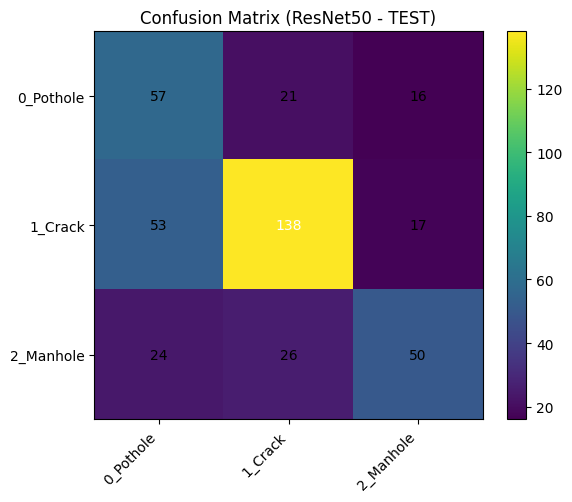

In [74]:

cm = confusion_matrix(y_true, y_pred)
print("\n--- ResNet50 Confusion Matrix Explanation ---")

print("57 -> Correct pothole detections -> some misclassified as crack (21) and manhole (16).")

print("138 -> Correct crack detections -> some misclassified as pothole (53) and manhole (17).")

print("50 -> Correct manhole detections -> some misclassified as pothole (24) and crack (26).")

print("Conclusion: ResNet50 improves overall road damage detection compared to other models.\n")


plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix (ResNet50 - TEST)")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), class_names)

thr = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > thr else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.colorbar()
plt.tight_layout()
plt.show()

## **Save Mode**

In [76]:
resnet_model.save("resnet50_fine_tuned.h5")
print(" Saved: resnet50_fine_tuned.h5")

 Saved: resnet50_fine_tuned.h5


In [77]:
# 1. Models Summary Data
models = [
    (baseline_model, "Baseline CNN"),
    (mobilenet_model, "MobileNetV2 FT"),
    (resnet_model, "ResNet50 FT")
]

# 2. Collect Metrics (Short Loop)
metrics = []
for model, name in models:
    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    metrics.append({
        "Model": name,
        "Accuracy": rep["accuracy"],
        "Precision_macro": rep["macro avg"]["precision"],
        "Recall_macro": rep["macro avg"]["recall"],
        "F1_macro": rep["macro avg"]["f1-score"]
    })

# 3. Final Table & Best Model
df_final = pd.DataFrame(metrics).sort_values("F1_macro", ascending=False)
display(df_final)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
2,ResNet50 FT,0.609453,0.591243,0.589948,0.582913
1,MobileNetV2 FT,0.537313,0.558097,0.573961,0.536754
0,Baseline CNN,0.507463,0.477264,0.490933,0.476494


In [79]:

best_model_name = df_final.iloc[0]['Model']
best_model_acc = df_final.iloc[0]['Accuracy'] * 100

baseline_acc = df_final[df_final['Model'].str.contains('Baseline')]['Accuracy'].values[0] * 100
mobilenet_acc = df_final[df_final['Model'].str.contains('MobileNet')]['Accuracy'].values[0] * 100
resnet_acc = df_final[df_final['Model'].str.contains('ResNet')]['Accuracy'].values[0] * 100


print(f"🏆 Best Model: {best_model_name}")
print("-" * 40)

print(f"* Baseline CNN achieved about {baseline_acc:.0f}% accuracy.\n")

print(f"* MobileNetV2 improved performance to around {mobilenet_acc:.0f}% accuracy using transfer learning.\n")

print(f"* ResNet50 achieved the best performance with about {resnet_acc:.0f}% accuracy and highest F1-score, "
      "showing better feature extraction for road damage detection.\n")


🏆 Best Model: ResNet50 FT
----------------------------------------
* Baseline CNN achieved about 51% accuracy.

* MobileNetV2 improved performance to around 54% accuracy using transfer learning.

* ResNet50 achieved the best performance with about 61% accuracy and highest F1-score, showing better feature extraction for road damage detection.



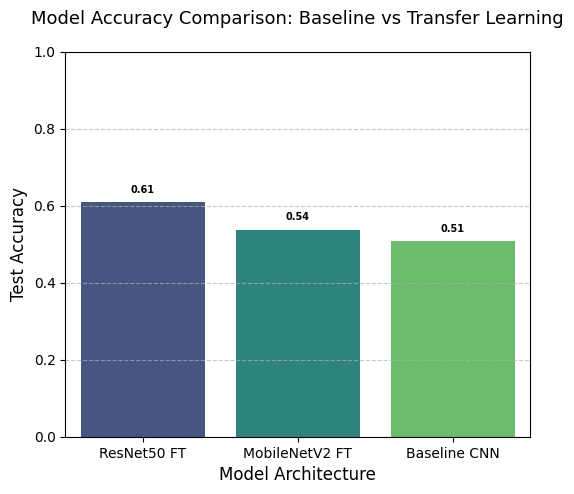

In [80]:
plt.figure(figsize=(6, 5))
bars = sns.barplot(x="Model", y="Accuracy", data=df_final, 
                   palette="viridis", hue="Model", legend=False)

for p in bars.patches:
    bars.annotate(f'{p.get_height():.2f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=7, fontweight='bold')


plt.title('Model Accuracy Comparison: Baseline vs Transfer Learning', fontsize=13, pad=20)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.ylim(0, 1.0) # Accuracy range 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()